# Notebook 04 — S&P 500 Return Analysis

This notebook performs dedicated return analysis on the validated S&P 500 master dataset.

**Input**
`data/raw/sp500_1950_present.csv`

**Focus**
- Simple and logarithmic returns
- Multi-horizon returns
- Return distributions
- Compounding
- Volatility scaling
- Downside risk
- Tail behavior
- Rolling return statistics
- Autocorrelation
- Up/down market behavior
- Drawdown and recovery characteristics
- Research-ready return tables

This notebook does not train models or modify the master dataset.


## 1. Imports

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("Imports loaded successfully.")


Imports loaded successfully.


## 2. Configuration and Paths

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if not (PROJECT_ROOT / "data").exists():
    candidates = [
        Path.cwd(),
        Path.cwd().parent,
        Path("/mnt/data/quant-trading-research"),
    ]
    for candidate in candidates:
        if (candidate / "data").exists() and (candidate / "notebooks").exists():
            PROJECT_ROOT = candidate
            break

MASTER_PATH = PROJECT_ROOT / "data" / "raw" / "sp500_1950_present.csv"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
TABLE_DIR = PROJECT_ROOT / "reports" / "tables"
REPORT_DIR = PROJECT_ROOT / "reports" / "generated"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_COLUMNS = [
    "Date",
    "Open",
    "High",
    "Low",
    "Close",
    "Adj.Close",
    "Volume",
]

print(f"Master dataset: {MASTER_PATH}")


Master dataset: d:\quant-trading-research\data\raw\sp500_1950_present.csv


## 3. Load the Master Dataset

In [3]:
if not MASTER_PATH.exists():
    raise FileNotFoundError(
        f"Master dataset not found: {MASTER_PATH}. "
        "Run Notebook 01 and Notebook 02 first."
    )

df = pd.read_csv(MASTER_PATH, low_memory=False)

if list(df.columns) != EXPECTED_COLUMNS:
    raise ValueError(
        f"Unexpected schema. Expected {EXPECTED_COLUMNS}, "
        f"received {list(df.columns)}"
    )

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

for column in EXPECTED_COLUMNS[1:]:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df = (
    df.sort_values("Date")
    .reset_index(drop=True)
)

if df["Date"].isna().any():
    raise ValueError("Invalid dates found.")

if df["Date"].duplicated().any():
    raise ValueError("Duplicate dates found.")

print(f"Rows: {len(df):,}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")


Rows: 19,273
Date range: 1950-01-03 → 2026-08-11


## 4. Construct Return Series

Returns are calculated from the persisted close prices.

- Simple return: `P_t / P_(t-1) - 1`
- Log return: `ln(P_t) - ln(P_(t-1))`


In [4]:
df["simple_return"] = df["Close"].pct_change()
df["log_return"] = np.log(df["Close"]).diff()

returns = df["simple_return"].dropna()
log_returns = df["log_return"].dropna()

print(f"Simple return observations: {len(returns):,}")
print(f"Log return observations: {len(log_returns):,}")


Simple return observations: 19,272
Log return observations: 19,272


## 5. Multi-Horizon Returns

Compute forward-looking research horizons using trailing historical prices:

- 1 trading day
- 5 trading days
- 21 trading days
- 63 trading days
- 126 trading days
- 252 trading days

These are historical trailing returns, not future labels.


In [5]:
horizons = {
    "1D": 1,
    "5D": 5,
    "21D": 21,
    "63D": 63,
    "126D": 126,
    "252D": 252,
}

for label, periods in horizons.items():
    df[f"return_{label}"] = (
        df["Close"] / df["Close"].shift(periods) - 1
    )

horizon_summary = pd.DataFrame({
    label: {
        "observations": int(df[f"return_{label}"].notna().sum()),
        "mean": df[f"return_{label}"].mean(),
        "median": df[f"return_{label}"].median(),
        "std": df[f"return_{label}"].std(),
        "min": df[f"return_{label}"].min(),
        "max": df[f"return_{label}"].max(),
    }
    for label in horizons
}).T

display(horizon_summary)

horizon_summary.to_csv(
    TABLE_DIR / "sp500_multi_horizon_return_summary.csv"
)


,observations,mean,median,std,min,max
1D,19272.0,0.000368,0.000504,0.009922,-0.204669,0.115800
5D,19268.0,0.001829,0.003002,0.021739,-0.273280,0.191112
21D,19252.0,0.007628,0.011205,0.043169,-0.329668,0.251144
63D,19210.0,0.022842,0.027193,0.073012,-0.417706,0.393957
126D,19147.0,0.046032,0.051363,0.107019,-0.464658,0.502372
252D,19021.0,0.094013,0.106101,0.158482,-0.488228,0.747797


## 6. Annualized Return and Volatility

Annualized statistics use approximately 252 trading sessions.

Volatility is scaled by square root of time as a descriptive convention.


In [6]:
annualized_stats = pd.DataFrame({
    "metric": [
        "Mean daily return",
        "Median daily return",
        "Daily volatility",
        "Annualized mean return",
        "Annualized volatility",
    ],
    "value": [
        returns.mean(),
        returns.median(),
        returns.std(),
        returns.mean() * 252,
        returns.std() * np.sqrt(252),
    ],
})

display(annualized_stats)

annualized_stats.to_csv(
    TABLE_DIR / "sp500_annualized_return_statistics.csv",
    index=False
)


,metric,value
0,Mean daily return,0.000368
1,Median daily return,0.000504
2,Daily volatility,0.009922
3,Annualized mean return,0.092757
4,Annualized volatility,0.157511


## 7. Geometric Annualized Return

The geometric estimate uses the total compounded wealth over the available history.


In [7]:
first_close = df["Close"].iloc[0]
last_close = df["Close"].iloc[-1]
years = (df["Date"].iloc[-1] - df["Date"].iloc[0]).days / 365.25

geometric_annualized_return = (
    (last_close / first_close) ** (1 / years) - 1
)

geometric_summary = pd.DataFrame({
    "metric": [
        "First close",
        "Last close",
        "Years",
        "Geometric annualized return",
    ],
    "value": [
        first_close,
        last_close,
        years,
        geometric_annualized_return,
    ],
})

display(geometric_summary)

geometric_summary.to_csv(
    TABLE_DIR / "sp500_geometric_return_summary.csv",
    index=False
)


,metric,value
0,First close,16.660000
1,Last close,7728.200195
2,Years,76.602327
3,Geometric annualized return,0.083449


## 8. Cumulative Wealth Index

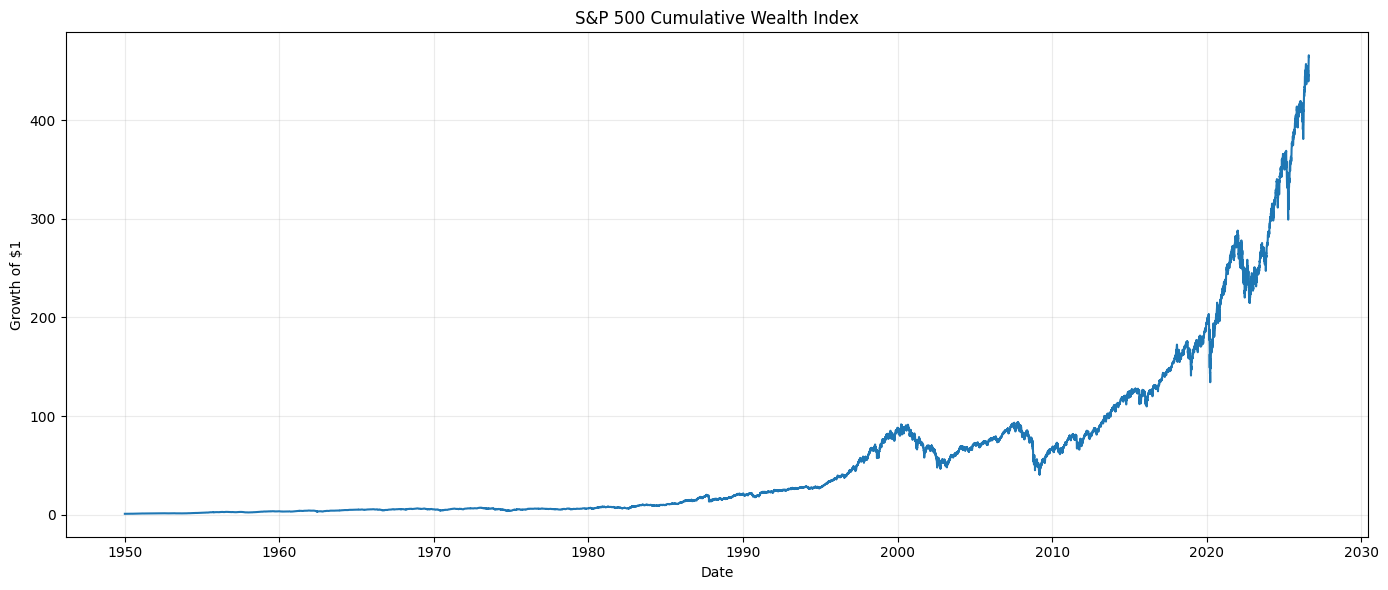

Saved: d:\quant-trading-research\reports\figures\sp500_cumulative_wealth_index.png


In [8]:
df["wealth_index"] = (
    1 + df["simple_return"].fillna(0)
).cumprod()

fig = plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["wealth_index"])
plt.title("S&P 500 Cumulative Wealth Index")
plt.xlabel("Date")
plt.ylabel("Growth of $1")
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_cumulative_wealth_index.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 9. Rolling Return Statistics

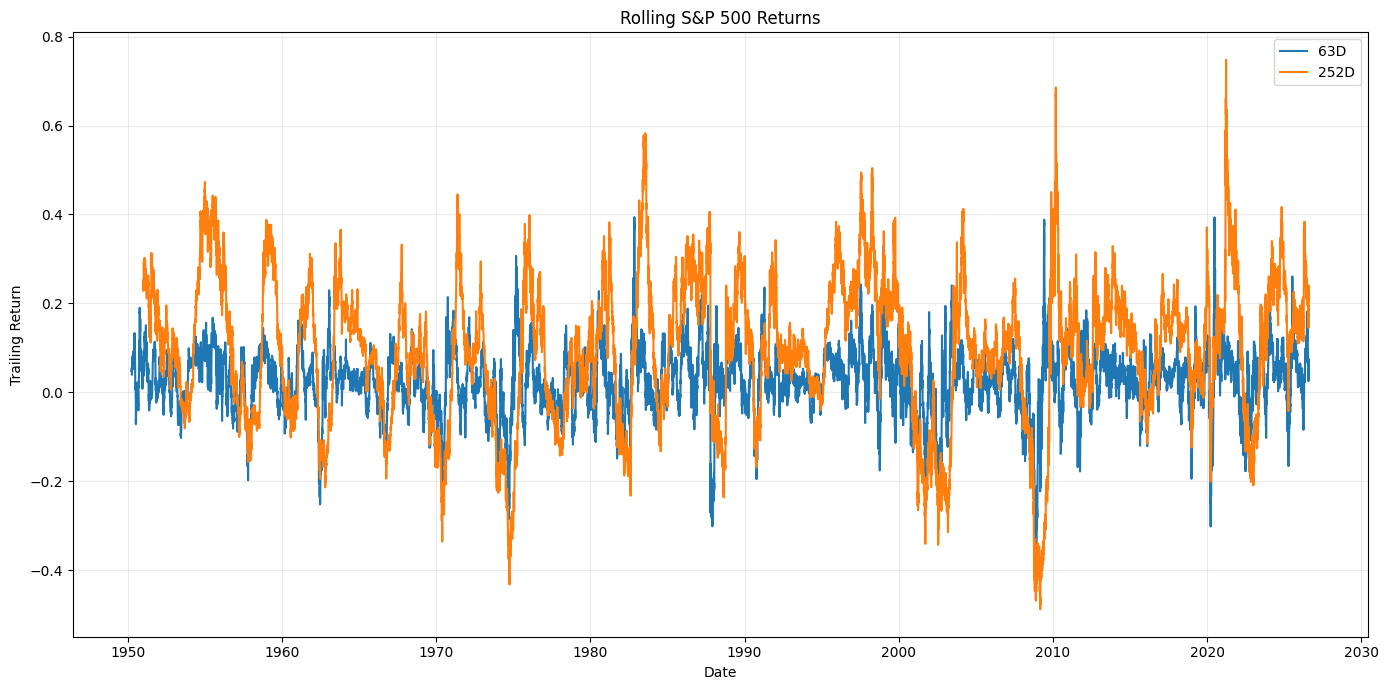

Saved: d:\quant-trading-research\reports\figures\sp500_rolling_returns.png


In [9]:
rolling_windows = {
    "21D": 21,
    "63D": 63,
    "126D": 126,
    "252D": 252,
}

for label, window in rolling_windows.items():
    df[f"rolling_return_{label}"] = (
        df["Close"] / df["Close"].shift(window) - 1
    )

fig = plt.figure(figsize=(14, 7))
plt.plot(df["Date"], df["rolling_return_63D"], label="63D")
plt.plot(df["Date"], df["rolling_return_252D"], label="252D")
plt.title("Rolling S&P 500 Returns")
plt.xlabel("Date")
plt.ylabel("Trailing Return")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_rolling_returns.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 10. Rolling Volatility

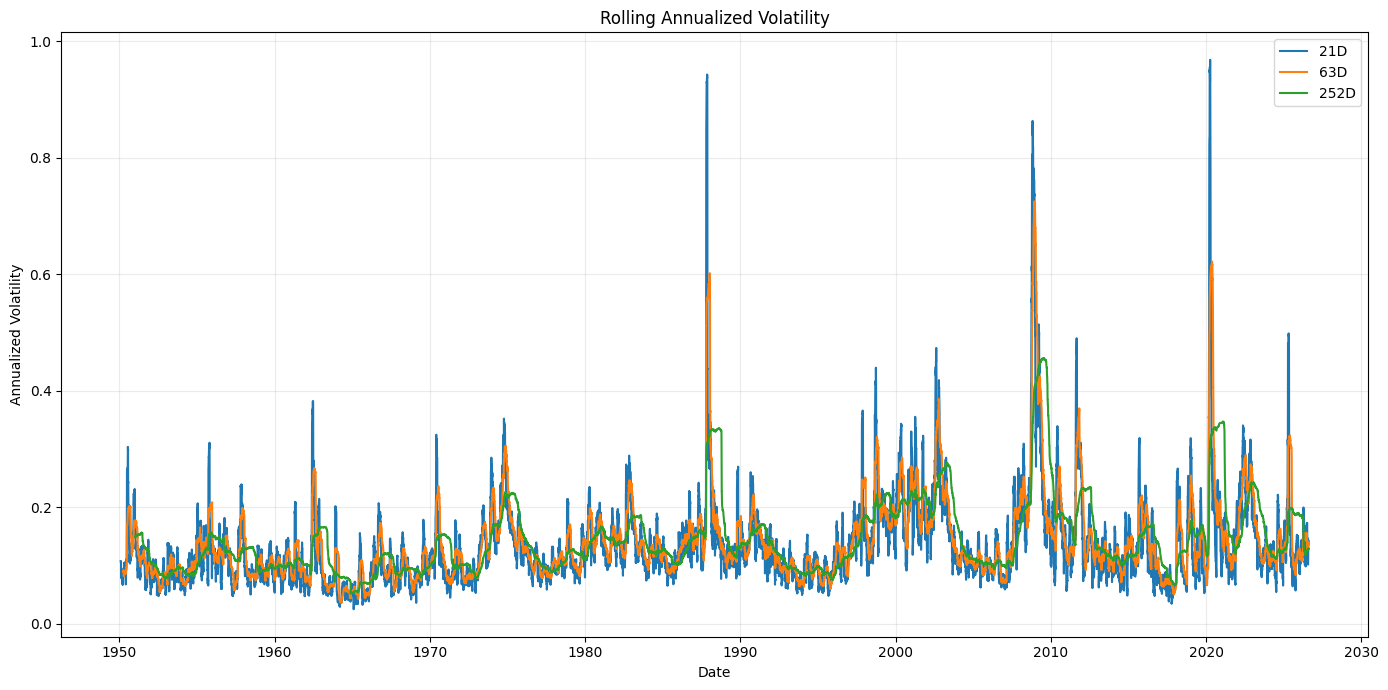

Saved: d:\quant-trading-research\reports\figures\sp500_return_rolling_volatility.png


In [10]:
for label, window in rolling_windows.items():
    df[f"rolling_vol_{label}"] = (
        df["simple_return"]
        .rolling(window)
        .std()
        * np.sqrt(252)
    )

fig = plt.figure(figsize=(14, 7))
plt.plot(df["Date"], df["rolling_vol_21D"], label="21D")
plt.plot(df["Date"], df["rolling_vol_63D"], label="63D")
plt.plot(df["Date"], df["rolling_vol_252D"], label="252D")
plt.title("Rolling Annualized Volatility")
plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_return_rolling_volatility.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 11. Downside and Upside Statistics

In [11]:
up_returns = returns[returns > 0]
down_returns = returns[returns < 0]

downside_deviation = down_returns.std()

upside_summary = {
    "positive_days": int(len(up_returns)),
    "negative_days": int(len(down_returns)),
    "zero_return_days": int((returns == 0).sum()),
    "positive_day_ratio": float((returns > 0).mean()),
    "negative_day_ratio": float((returns < 0).mean()),
    "mean_positive_return": float(up_returns.mean()),
    "mean_negative_return": float(down_returns.mean()),
    "median_positive_return": float(up_returns.median()),
    "median_negative_return": float(down_returns.median()),
    "downside_deviation": float(downside_deviation),
}

display(pd.DataFrame(
    upside_summary.items(),
    columns=["metric", "value"]
))

pd.DataFrame(
    upside_summary.items(),
    columns=["metric", "value"]
).to_csv(
    TABLE_DIR / "sp500_upside_downside_statistics.csv",
    index=False
)


,metric,value
0,positive_days,10243.000000
1,negative_days,8904.000000
2,zero_return_days,125.000000
3,positive_day_ratio,0.531496
4,negative_day_ratio,0.462017
5,mean_positive_return,0.006615
6,mean_negative_return,-0.006813
7,median_positive_return,0.004711
8,median_negative_return,-0.004618
9,downside_deviation,0.007779


## 12. Skewness and Kurtosis

In [12]:
distribution_stats = pd.DataFrame({
    "metric": [
        "Mean",
        "Median",
        "Std",
        "Skewness",
        "Excess Kurtosis",
        "Minimum",
        "Maximum",
    ],
    "simple_return": [
        returns.mean(),
        returns.median(),
        returns.std(),
        returns.skew(),
        returns.kurt(),
        returns.min(),
        returns.max(),
    ],
    "log_return": [
        log_returns.mean(),
        log_returns.median(),
        log_returns.std(),
        log_returns.skew(),
        log_returns.kurt(),
        log_returns.min(),
        log_returns.max(),
    ],
})

display(distribution_stats)

distribution_stats.to_csv(
    TABLE_DIR / "sp500_return_distribution_statistics.csv",
    index=False
)


,metric,simple_return,log_return
0,Mean,0.000368,0.000319
1,Median,0.000504,0.000503
2,Std,0.009922,0.009959
3,Skewness,-0.588014,-0.948685
4,Excess Kurtosis,20.022609,25.187943
5,Minimum,-0.204669,-0.228997
6,Maximum,0.115800,0.109572


## 13. Quantile / Tail Analysis

In [13]:
quantiles = [
    0.001,
    0.005,
    0.01,
    0.025,
    0.05,
    0.10,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.975,
    0.99,
    0.995,
    0.999,
]

tail_quantiles = (
    returns.quantile(quantiles)
    .rename("return")
    .to_frame()
)

tail_quantiles.index.name = "quantile"

display(tail_quantiles)

tail_quantiles.to_csv(
    TABLE_DIR / "sp500_return_tail_quantiles.csv"
)


,return
quantile,
0.001,-0.059531
0.005,-0.033339
0.010,-0.026917
0.025,-0.019310
0.050,-0.014749
0.100,-0.010052
0.250,-0.004053
0.500,0.000504
0.750,0.005103


## 14. Value at Risk and Expected Shortfall

Historical, non-parametric estimates:

- VaR at 95% and 99% confidence
- Expected Shortfall as the average return below the corresponding VaR threshold

These are descriptive historical measures, not forecasts.


In [14]:
risk_levels = [0.95, 0.99]

var_es_rows = []

for confidence in risk_levels:
    alpha = 1 - confidence
    var_threshold = returns.quantile(alpha)
    expected_shortfall = returns[returns <= var_threshold].mean()

    var_es_rows.append({
        "confidence": confidence,
        "VaR_return_threshold": var_threshold,
        "Expected_Shortfall": expected_shortfall,
    })

var_es = pd.DataFrame(var_es_rows)

display(var_es)

var_es.to_csv(
    TABLE_DIR / "sp500_historical_var_expected_shortfall.csv",
    index=False
)


,confidence,VaR_return_threshold,Expected_Shortfall
0,0.95,-0.014749,-0.023032
1,0.99,-0.026917,-0.039599


## 15. Return Distribution with Tail Thresholds

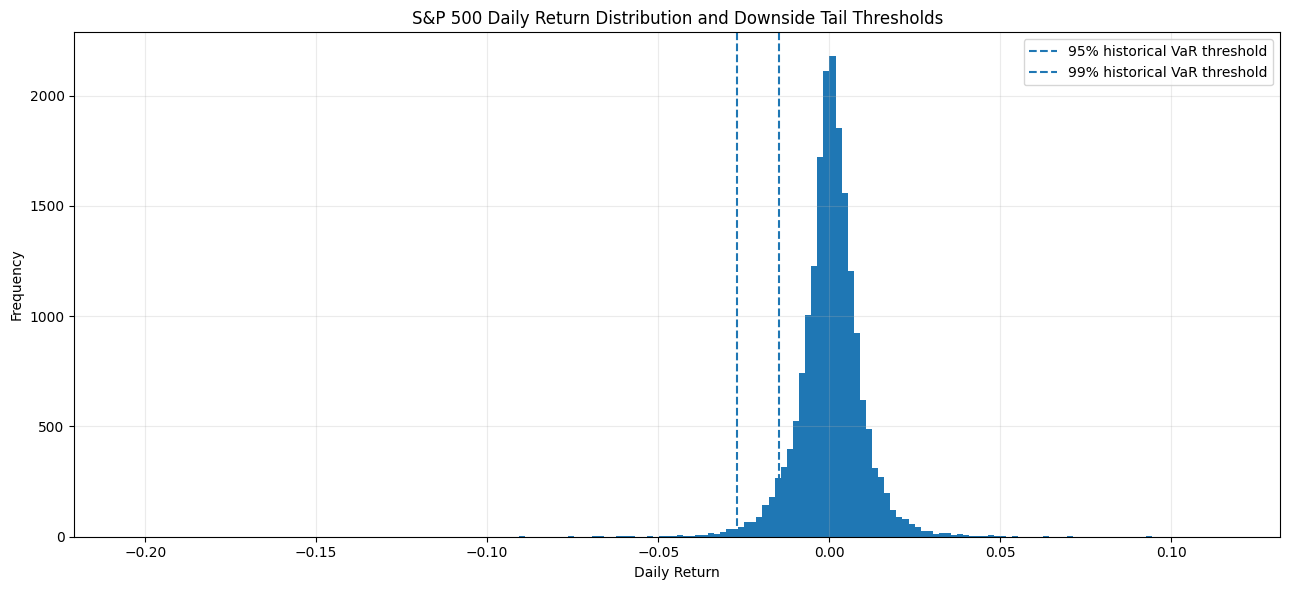

Saved: d:\quant-trading-research\reports\figures\sp500_return_distribution_var.png


In [15]:
var_95 = var_es.loc[
    var_es["confidence"] == 0.95,
    "VaR_return_threshold"
].iloc[0]

var_99 = var_es.loc[
    var_es["confidence"] == 0.99,
    "VaR_return_threshold"
].iloc[0]

fig = plt.figure(figsize=(13, 6))
plt.hist(returns, bins=180)
plt.axvline(
    var_95,
    linestyle="--",
    label="95% historical VaR threshold"
)
plt.axvline(
    var_99,
    linestyle="--",
    label="99% historical VaR threshold"
)
plt.title("S&P 500 Daily Return Distribution and Downside Tail Thresholds")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_return_distribution_var.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 16. Return Autocorrelation

,lag,autocorrelation
0,1,-0.002686
1,2,-0.019854
2,3,-0.006653
3,4,-0.017120
4,5,-0.004995
5,6,-0.023822
6,7,0.007165
7,8,-0.012989
8,9,0.016541
9,10,0.000713


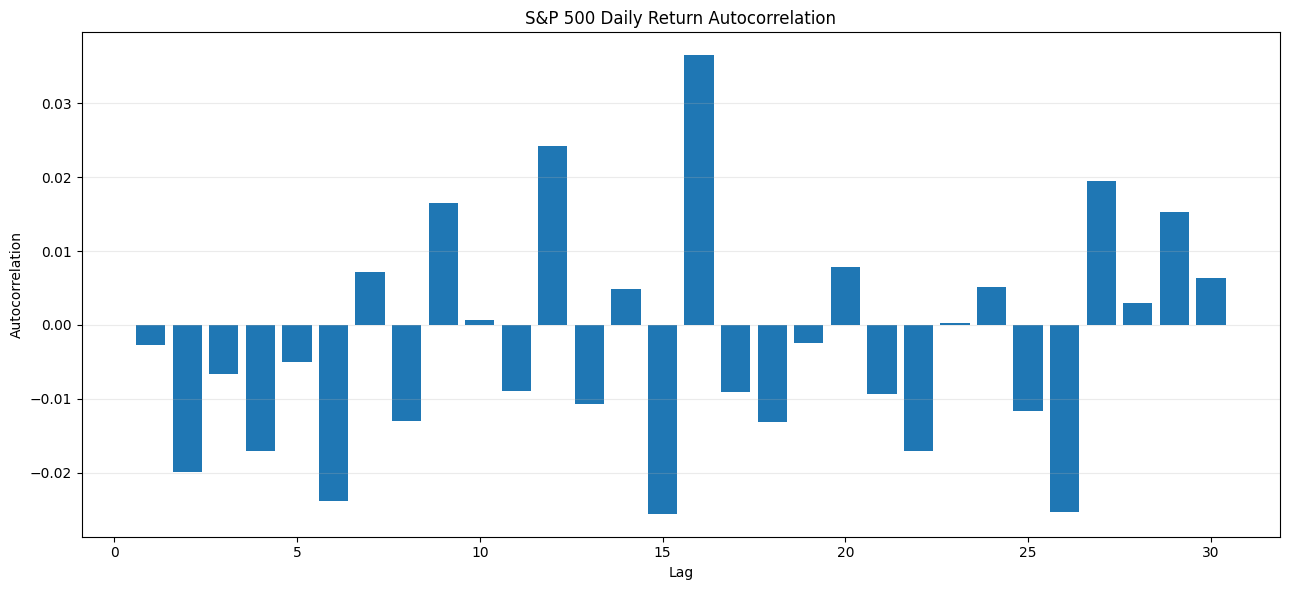

Saved: d:\quant-trading-research\reports\figures\sp500_return_autocorrelation_30_lags.png


In [16]:
return_autocorrelation = pd.DataFrame({
    "lag": range(1, 31),
    "autocorrelation": [
        returns.autocorr(lag=i)
        for i in range(1, 31)
    ],
})

display(return_autocorrelation)

return_autocorrelation.to_csv(
    TABLE_DIR / "sp500_return_autocorrelation_30_lags.csv",
    index=False
)

fig = plt.figure(figsize=(13, 6))
plt.bar(
    return_autocorrelation["lag"],
    return_autocorrelation["autocorrelation"]
)
plt.title("S&P 500 Daily Return Autocorrelation")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_return_autocorrelation_30_lags.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 17. Absolute and Squared Return Dependence

These statistics are useful for studying volatility clustering.


In [17]:
dependence_rows = []

for lag in range(1, 31):
    dependence_rows.append({
        "lag": lag,
        "return_autocorrelation": returns.autocorr(lag=lag),
        "absolute_return_autocorrelation": returns.abs().autocorr(lag=lag),
        "squared_return_autocorrelation": (returns ** 2).autocorr(lag=lag),
    })

dependence = pd.DataFrame(dependence_rows)

display(dependence)

dependence.to_csv(
    TABLE_DIR / "sp500_return_dependence_statistics.csv",
    index=False
)


,lag,return_autocorrelation,absolute_return_autocorrelation,squared_return_autocorrelation
0,1,-0.002686,0.268747,0.224231
1,2,-0.019854,0.298500,0.292864
2,3,-0.006653,0.274765,0.174724
3,4,-0.017120,0.268111,0.162151
4,5,-0.004995,0.291152,0.226858
5,6,-0.023822,0.260403,0.167892
6,7,0.007165,0.252742,0.149556
7,8,-0.012989,0.249125,0.154056
8,9,0.016541,0.246866,0.154130
9,10,0.000713,0.238626,0.128294


## 18. Up-Day / Down-Day Conditional Analysis

In [18]:
df["previous_return"] = df["simple_return"].shift(1)

conditional_summary = pd.DataFrame({
    "Following Up Day": df.loc[
        df["previous_return"] > 0,
        "simple_return"
    ].describe(),
    "Following Down Day": df.loc[
        df["previous_return"] < 0,
        "simple_return"
    ].describe(),
})

display(conditional_summary)

conditional_summary.to_csv(
    TABLE_DIR / "sp500_conditional_return_summary.csv"
)


,Following Up Day,Following Down Day
count,10243.000000,8903.000000
mean,0.000786,-0.000110
std,0.008981,0.010922
min,-0.119841,-0.204669
25%,-0.003182,-0.005240
50%,0.000822,0.000120
75%,0.005212,0.005024
max,0.090994,0.115800


## 19. Consecutive Up/Down Streaks

In [19]:
direction = np.sign(df["simple_return"]).fillna(0)

groups = (direction != direction.shift()).cumsum()

streaks = (
    pd.DataFrame({
        "direction": direction,
        "group": groups,
    })
    .groupby(["group", "direction"])
    .size()
    .reset_index(name="length")
)

streaks["type"] = np.select(
    [
        streaks["direction"] > 0,
        streaks["direction"] < 0,
    ],
    [
        "up",
        "down",
    ],
    default="flat",
)

up_streaks = streaks.loc[streaks["type"] == "up", "length"]
down_streaks = streaks.loc[streaks["type"] == "down", "length"]

streak_summary = pd.DataFrame({
    "metric": [
        "Maximum up streak",
        "Maximum down streak",
        "Mean up streak",
        "Mean down streak",
    ],
    "value": [
        up_streaks.max(),
        down_streaks.max(),
        up_streaks.mean(),
        down_streaks.mean(),
    ],
})

display(streak_summary)

streak_summary.to_csv(
    TABLE_DIR / "sp500_up_down_streak_summary.csv",
    index=False
)


,metric,value
0,Maximum up streak,14.000000
1,Maximum down streak,12.000000
2,Mean up streak,2.248244
3,Mean down streak,1.961233


## 20. Drawdown and Recovery Analysis

In [20]:
df["wealth"] = (
    1 + df["simple_return"].fillna(0)
).cumprod()

df["running_peak"] = df["wealth"].cummax()
df["drawdown"] = df["wealth"] / df["running_peak"] - 1

max_drawdown = df["drawdown"].min()
max_drawdown_date = df.loc[df["drawdown"].idxmin(), "Date"]

# Recovery date: first date after the maximum drawdown when the prior peak is recovered.
peak_before_drawdown = df.loc[
    df["drawdown"].idxmin(),
    "running_peak"
]

recovery_candidates = df.loc[
    (df["Date"] > max_drawdown_date) &
    (df["wealth"] >= peak_before_drawdown),
    "Date"
]

recovery_date = (
    recovery_candidates.iloc[0]
    if len(recovery_candidates)
    else pd.NaT
)

drawdown_summary = pd.DataFrame({
    "metric": [
        "Maximum drawdown",
        "Maximum drawdown date",
        "Recovery date",
        "Recovery duration days",
    ],
    "value": [
        max_drawdown,
        max_drawdown_date.date(),
        recovery_date.date() if not pd.isna(recovery_date) else None,
        (
            (recovery_date - max_drawdown_date).days
            if not pd.isna(recovery_date)
            else None
        ),
    ],
})

display(drawdown_summary)

drawdown_summary.to_csv(
    TABLE_DIR / "sp500_max_drawdown_recovery_summary.csv",
    index=False
)


,metric,value
0,Maximum drawdown,-0.567754
1,Maximum drawdown date,2009-03-09
2,Recovery date,2013-03-28
3,Recovery duration days,1480


## 21. Rolling Sharpe-Like Statistic

This descriptive statistic uses a rolling mean divided by rolling standard deviation and annualizes by the conventional 252-session factor.

It is not a portfolio-level Sharpe ratio because it does not model a risk-free rate, transaction costs, or portfolio construction.


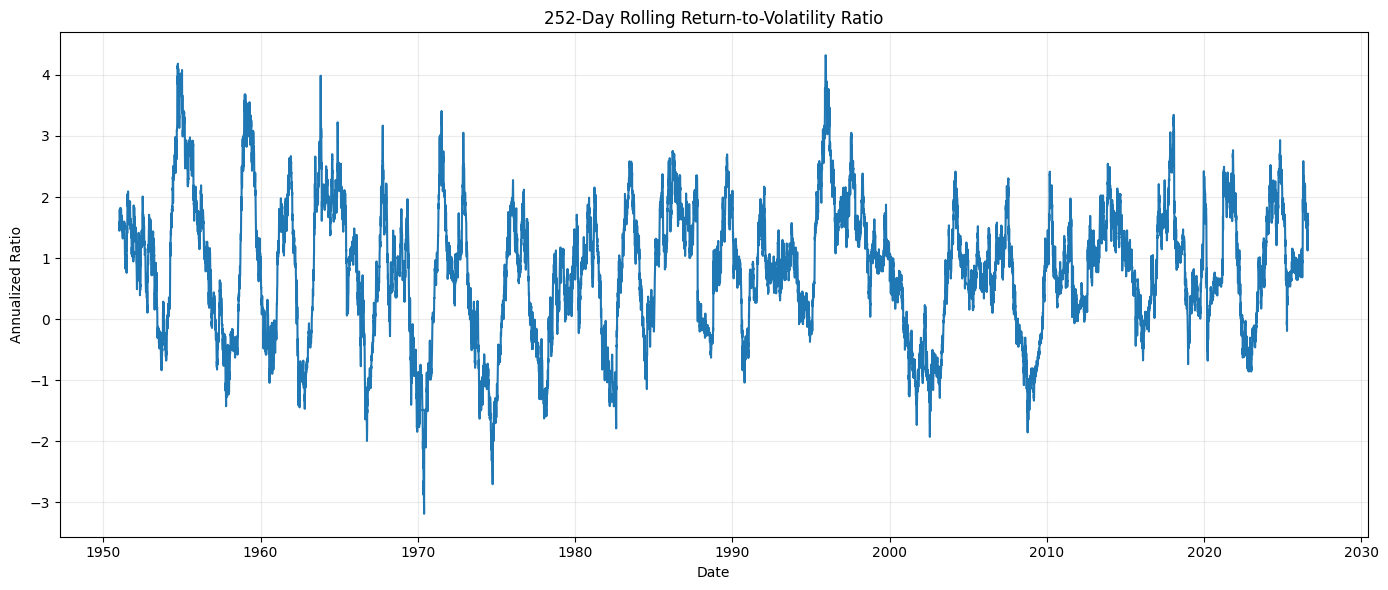

Saved: d:\quant-trading-research\reports\figures\sp500_252d_rolling_sharpe_like.png


In [21]:
for window in [21, 63, 252]:
    rolling_mean = df["simple_return"].rolling(window).mean()
    rolling_std = df["simple_return"].rolling(window).std()

    df[f"rolling_sharpe_{window}d"] = (
        rolling_mean / rolling_std * np.sqrt(252)
    )

fig = plt.figure(figsize=(14, 6))
plt.plot(
    df["Date"],
    df["rolling_sharpe_252d"]
)
plt.title("252-Day Rolling Return-to-Volatility Ratio")
plt.xlabel("Date")
plt.ylabel("Annualized Ratio")
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_252d_rolling_sharpe_like.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 22. Monthly Return Distribution

,monthly_return
count,919.000000
mean,0.007557
std,0.041809
min,-0.217630
25%,-0.017235
50%,0.009980
75%,0.035228
max,0.163047


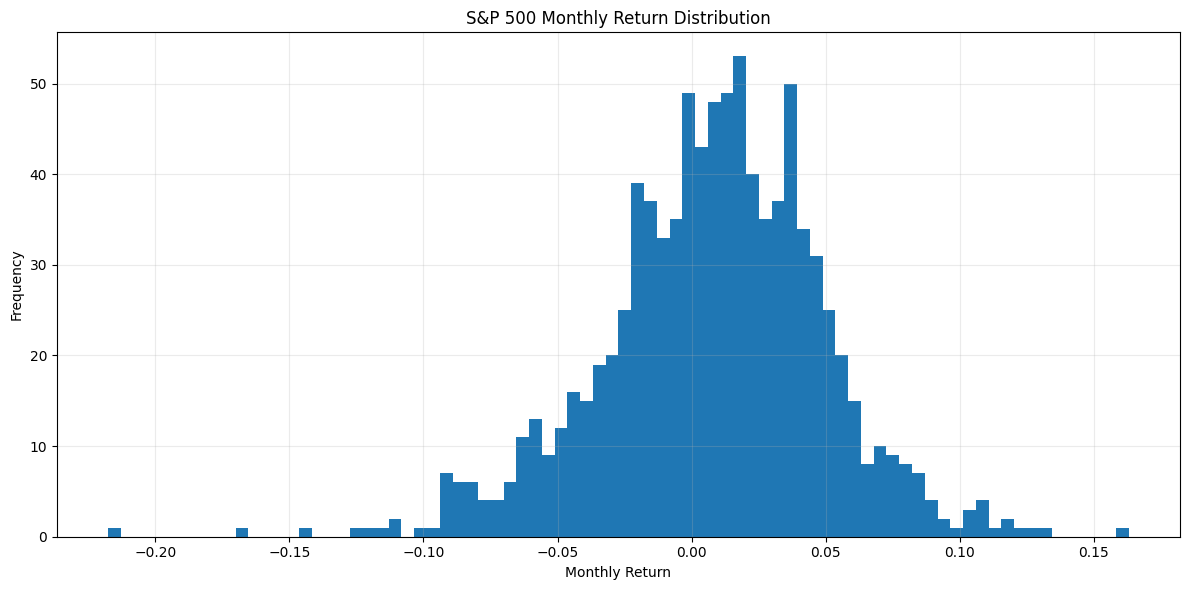

Saved: d:\quant-trading-research\reports\figures\sp500_monthly_return_distribution.png


In [23]:
monthly_returns = (
    df.set_index("Date")["Close"]
    .resample("M")
    .last()
    .pct_change()
    .dropna()
)

monthly_summary = monthly_returns.describe()

display(monthly_summary.to_frame("monthly_return"))

monthly_returns.to_frame("monthly_return").to_csv(
    TABLE_DIR / "sp500_monthly_returns.csv"
)

fig = plt.figure(figsize=(12, 6))
plt.hist(monthly_returns, bins=80)
plt.title("S&P 500 Monthly Return Distribution")
plt.xlabel("Monthly Return")
plt.ylabel("Frequency")
plt.grid(True, alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_monthly_return_distribution.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 23. Quarterly Return Distribution

In [ ]:
quarterly_returns = (
    df.set_index("Date")["Close"]
    .resample("Q")
    .last()
    .pct_change()
    .dropna()
)

display(quarterly_returns.describe().to_frame("quarterly_return"))

quarterly_returns.to_frame("quarterly_return").to_csv(
    TABLE_DIR / "sp500_quarterly_returns.csv"
)


ValueError: Invalid frequency: QE

## 24. Calendar Month Seasonality

This is descriptive seasonality only. It is not a trading strategy.


In [ ]:
df["calendar_month"] = df["Date"].dt.month

month_summary = (
    df.groupby("calendar_month")["simple_return"]
    .agg(
        observations="count",
        mean="mean",
        median="median",
        std="std",
        positive_rate=lambda x: (x > 0).mean(),
    )
    .reset_index()
)

display(month_summary)

month_summary.to_csv(
    TABLE_DIR / "sp500_calendar_month_return_summary.csv",
    index=False
)

fig = plt.figure(figsize=(12, 6))
plt.bar(
    month_summary["calendar_month"],
    month_summary["mean"]
)
plt.title("Average S&P 500 Daily Return by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Mean Daily Return")
plt.xticks(range(1, 13))
plt.grid(True, axis="y", alpha=0.25)
plt.tight_layout()

path = FIGURE_DIR / "sp500_monthly_seasonality.png"
fig.savefig(path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved: {path}")


## 25. Return Regime Statistics

Returns are grouped into simple descriptive magnitude buckets for exploratory analysis.


In [ ]:
df["return_bucket"] = pd.cut(
    df["simple_return"],
    bins=[
        -np.inf,
        -0.05,
        -0.02,
        0.00,
        0.02,
        0.05,
        np.inf,
    ],
    labels=[
        "<=-5%",
        "-5% to -2%",
        "-2% to 0%",
        "0% to 2%",
        "2% to 5%",
        ">5%",
    ],
    include_lowest=True,
)

return_bucket_summary = (
    df.groupby("return_bucket", observed=False)
    .agg(
        observations=("simple_return", "count"),
        mean_return=("simple_return", "mean"),
        median_return=("simple_return", "median"),
    )
    .reset_index()
)

return_bucket_summary["percentage_of_observations"] = (
    return_bucket_summary["observations"] /
    return_bucket_summary["observations"].sum()
)

display(return_bucket_summary)

return_bucket_summary.to_csv(
    TABLE_DIR / "sp500_return_magnitude_buckets.csv",
    index=False
)


## 26. Save Research Dataset

The enriched research dataframe is saved to `data/interim/` rather than replacing the master raw CSV.

This allows later notebooks to reuse the derived return fields without altering the original acquisition dataset.


In [ ]:
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

research_output = INTERIM_DIR / "sp500_return_analysis.parquet"

df.to_parquet(
    research_output,
    index=False
)

print(f"Saved research dataset: {research_output}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")


## 27. Final Return-Analysis Report

In [ ]:
report = {
    "dataset": {
        "rows": int(len(df)),
        "start": df["Date"].min().strftime("%Y-%m-%d"),
        "end": df["Date"].max().strftime("%Y-%m-%d"),
    },
    "returns": {
        "observations": int(len(returns)),
        "mean_daily_return": float(returns.mean()),
        "median_daily_return": float(returns.median()),
        "daily_volatility": float(returns.std()),
        "annualized_volatility": float(returns.std() * np.sqrt(252)),
        "geometric_annualized_return": float(geometric_annualized_return),
        "skewness": float(returns.skew()),
        "excess_kurtosis": float(returns.kurt()),
    },
    "tail_risk": {
        "historical_var_95": float(var_95),
        "historical_var_99": float(var_99),
        "expected_shortfall_95": float(
            var_es.loc[
                var_es["confidence"] == 0.95,
                "Expected_Shortfall"
            ].iloc[0]
        ),
        "expected_shortfall_99": float(
            var_es.loc[
                var_es["confidence"] == 0.99,
                "Expected_Shortfall"
            ].iloc[0]
        ),
    },
    "drawdown": {
        "maximum_drawdown": float(max_drawdown),
        "maximum_drawdown_date": max_drawdown_date.strftime("%Y-%m-%d"),
        "recovery_date": (
            recovery_date.strftime("%Y-%m-%d")
            if not pd.isna(recovery_date)
            else None
        ),
    },
}

report_path = REPORT_DIR / "sp500_return_analysis_report.json"

report_path.write_text(
    json.dumps(report, indent=2),
    encoding="utf-8"
)

print(json.dumps(report, indent=2))
print(f"\nSaved: {report_path}")


## 28. Final Master Dataset Integrity Check

Notebook 04 must not modify the raw acquisition dataset.

The final check reloads the master CSV and verifies its schema and row count.


In [ ]:
master_check = pd.read_csv(
    MASTER_PATH,
    low_memory=False
)

assert list(master_check.columns) == EXPECTED_COLUMNS
assert len(master_check) == len(df)
assert pd.to_datetime(
    master_check["Date"],
    errors="coerce"
).notna().all()

print("Raw master dataset integrity after return analysis: PASS")
print(f"Master rows: {len(master_check):,}")
print(f"Master columns: {list(master_check.columns)}")


# Notebook 04 Complete

Notebook 04 has completed dedicated S&P 500 return research.

### Main outputs

- Simple and log returns
- 1D/5D/21D/63D/126D/252D returns
- Annualized return and volatility
- Geometric annualized return
- Cumulative wealth
- Rolling returns
- Rolling volatility
- Upside/downside statistics
- Skewness and kurtosis
- Tail quantiles
- Historical VaR and Expected Shortfall
- Return autocorrelation
- Volatility-clustering diagnostics
- Conditional up/down-day analysis
- Streak analysis
- Drawdown and recovery
- Monthly and quarterly returns
- Calendar-month seasonality
- Return-magnitude buckets
- Research-ready tables and figures

**Next notebook:** Notebook 05 — Factor Research.

Run Notebook 04 from top to bottom and verify the outputs before proceeding.
